# Sundlaug Country — 03 Technical Report

**Project:** Cross-country comparison of public swimming pool infrastructure, with focus on Iceland (high outlier) and the United States (low outlier relative to its developed-European peers in this sample).

**This notebook's scope:** Technical report for academic peer review. Documents methodology, presents findings, places findings in historical context, and acknowledges limitations.

**Intended audience:** Faculty reviewer (sociology and ethics) and downstream readers of the somewhere-else.org publication.

**Inputs:**
- `data/processed/country_analysis_results.csv` (from Notebook 02 — country data with uncertainty bounds)
- `data/processed/sensitivity_scenarios.csv` (from Notebook 02 — alternative definitions)
- `outputs/country_comparison_chart.png` (from Notebook 02 — primary figure)
- `outputs/us_historical_anchors_chart.png` (from Notebook 02 — historical context figure)

**Outputs:**
- This notebook, exported to HTML for reviewer submission
- `outputs/sundlaug_country_report.html` (rendered version for handoff)

**Methodological position:** Descriptive comparative analysis with bounded uncertainty quantification and sensitivity-to-definitional-choices testing. No inferential statistics, no causal modeling. The historical interpretation in Section 3 is attributed to Wiltse (2007) via secondary sources; primary-source consultation was not feasible within the project timeline. This dependency is treated as a limitation in Section 4.

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

# Paths
DATA_PROCESSED = Path('../data/processed')
OUTPUTS = Path('../outputs')

# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.2f}'.format)

# Load analytical results from Notebook 02
country_data = pd.read_csv(DATA_PROCESSED / 'country_analysis_results.csv')
sensitivity = pd.read_csv(DATA_PROCESSED / 'sensitivity_scenarios.csv')

print(f'Loaded {len(country_data)} countries with full analytical results.')
print(f'Loaded {len(sensitivity)} sensitivity scenarios.')

Loaded 5 countries with full analytical results.
Loaded 8 sensitivity scenarios.


## Abstract

Public swimming pools function as both recreational facilities and civic infrastructure, but the density at which countries build and maintain them varies dramatically. This report documents the public swimming pool density of five countries (Iceland, Finland, Sweden, United Kingdom, United States) and quantifies the cross-country variation.

We applied a strict definition of public pool — facilities operated by local government or government-licensed nonprofits, open to the public for a per-visit fee, in year-round operation — and sourced counts from authoritative national directories and industry research. Per-capita rates were computed with bounded uncertainty reflecting both population estimate variability and count uncertainty. Sensitivity analyses tested the robustness of headline findings against defensible alternative definitions.

Three findings emerge. First, Iceland is an extreme outlier at 23.5 public pools per 100,000 residents — approximately five to six times the rate of any other country in the dataset. Second, three developed European countries (Sweden, United Kingdom, Finland) form a tight cluster between 3.5 and 4.3 pools per 100,000 within this sample. Third, the United States sits substantially below this cluster at 1.6 pools per 100,000, roughly half the rate of these three European peers. The Iceland-as-outlier finding is robust to alternative definitions; the US gap is robust to count-range uncertainty.

This is descriptive comparative analysis. The historical-causal account of the US gap, advanced by historian Jeff Wiltse in *Contested Waters* (2007) and centered on desegregation-era pool closures, is treated in Section 3 as context derived from secondary sources rather than as an analytical claim of this report.

We note at the outset that the strict definition applied here means the comparison partly reflects how each country socializes recreational infrastructure, not solely how many bathing facilities exist within its borders. This framing is developed further in Section 4.6.

## 1. Methodology

### 1.1 Research question and approach

This report addresses a focused empirical question: how does the per-capita density of public swimming pools vary across a small set of developed countries, and how robust is the observed variation to defensible alternative definitions?

The analytical approach is descriptive comparative analysis. We do not advance causal claims about why the variation exists; we document what the variation is and test its robustness. Where historical interpretation appears (Section 3), it is attributed to secondary sources rather than developed independently.

The countries selected — Iceland, Finland, Sweden, United Kingdom, and United States — were chosen for two reasons. First, each has an authoritative or near-authoritative national source for public pool counts, enabling consistent measurement. Second, the set spans the analytical structure of interest: one expected high outlier (Iceland), three developed European peers expected to cluster (Finland, Sweden, UK), and one expected low outlier (United States). Selection on this structure is acknowledged as a limitation in Section 4.

### 1.2 Definitional choices

Public swimming pool counts vary substantially depending on what facilities are included. To enable cross-country comparability, we applied a strict definition:

A facility was counted as a public pool if it met all four criteria:

1. **Operated by local government, municipality, or government-licensed nonprofit organization.** Private clubs, hotel pools, and commercial fitness facilities were excluded.
2. **Open to the general public for a per-visit fee.** Facilities accessible only by membership or institutional affiliation (corporate, school, residential) were excluded.
3. **Year-round operation.** Seasonal-only pools were excluded.
4. **Constructed facility, not natural feature.** Natural hot springs and unimproved bathing pools were excluded even where publicly accessible.

This definition is conservative — it produces lower counts than more inclusive definitions used in tourism literature or general industry reporting. The conservatism is intentional: a strict definition applied consistently across all countries produces more defensible cross-country comparison than a permissive definition that might count different categories of facility in different national contexts.

Three of the five countries had defensible alternative definitions that would have produced meaningfully different counts. These alternatives are tested for robustness in Section 2.2.

### 1.3 Data sources

For each country, we sourced the pool count from the most authoritative national source available. Where authoritative government statistics existed, those were preferred. Where they did not, we used industry research or national sport federation data.

| Country | Count | Source |
|---|---|---|
| Iceland | 93 | sundlaugar.is (national pool directory) |
| Finland | 198 | LIPAS database via University of Jyväskylä academic research |
| Sweden | ~450 | BeFair industry research and Swedish Swimming Federation |
| United Kingdom | 2,646 | Leisure DB 2024 State of UK Swimming Industry Report |
| United States | ~5,500 | Trust for Public Land via Swimply analysis |

Iceland's count is the result of a hand enumeration of the consolidated national directory at sundlaugar.is, applying the strict definition. The directory listed 100 entries; seven were excluded as lagoons (3), hot springs (2), or natural pools (2). The remaining 93 facilities are all operated by municipalities or municipal subsidiaries and meet all four definitional criteria. A cross-check against the published count of pools in the greater Reykjavík capital area (18) matched our enumeration, providing partial verification of the directory's completeness. The sundlaugar.is directory is publicly accessible and the categorical exclusions documented above can be verified against the live listing by any reader who repeats the enumeration.

Finland's count is drawn from a 2015 academic research paper (Oulu University) citing the LIPAS database, which is Finland's national sport facility GIS system maintained in cooperation with the Ministry of Education and Culture. The 198 figure represents indoor swimming halls (*uimahalli*). Finland has separate categories for outdoor pools (*maauimala*) and spas (*kylpylä*), neither of which are included in the 198 figure. This is a notable definitional discrepancy — see sensitivity analysis in Section 2.2.

Sweden's count is approximately 450 public swimming halls (*offentliga simhallar*), per industry research (BeFair) confirmed by the Swedish Swimming Federation. Roughly 85% are operated directly by municipal entities; the remaining 15% are operated by private companies under municipal contract. Under the definition applied here, both are counted as public. We note that Nordic recreation systems often involve hybrid operational arrangements — municipal ownership combined with nonprofit or subsidized-private operation — that a binary public/private classification does not fully capture. The 85/15 split should be read as an approximate categorization rather than as a clean operational boundary.

The United Kingdom's count is 2,646 pools across 1,603 public leisure centres, per the Leisure DB 2024 State of UK Swimming Industry Report. As in Sweden, UK pools are commonly owned by local authorities but operated by private leisure-management companies (GLL, Everyone Active, Freedom Leisure) under municipal contract. All such facilities are counted as public. Our specific inclusion rule was to count every facility listed in the Leisure DB report as a publicly-accessible swimming pool, regardless of whether day-to-day operation is performed by council-employed staff or by a private contractor under municipal contract. An alternative, narrower count of 898 facilities (directly council-operated only) is tested in Section 2.2.

The United States count is an estimate. Unlike the other four countries, the US has no authoritative national directory of public pools. The 5,500 figure is the midpoint of a 5,000–6,000 plausible range, derived from a Trust for Public Land analysis of the 100 most populous US cities (median 1.8 pools per 100,000 residents, scaled to national population). Definitional alignment with the other countries is good: Trust for Public Land's methodology excludes splash pads, wading pools, and private-club facilities. The full Trust for Public Land methodology — including their inclusion and exclusion criteria — is documented in their underlying publication, accessible via the Swimply analytical report cited in Section 5.

### 1.4 Uncertainty treatment

Per-capita rates are reported with uncertainty bounds rather than as point estimates. Two sources of uncertainty contribute, with their relative importance differing by country:

**Population estimate uncertainty.** National population figures from official statistics agencies and OECD reporting have small but nonzero uncertainty (typically <2%). For Iceland, Finland, Sweden, and the United Kingdom, this is the only meaningful source of variability since pool counts are based on enumerated directories. We applied a uniform ±2% population uncertainty band across these countries.

**Count uncertainty.** For the United States, the pool count itself is the dominant uncertainty source. The 5,500 figure is a midpoint of a 5,000–6,000 plausible range; this range was carried through to the per-capita calculation. Combined with the same ±2% population uncertainty, the US per-capita rate is reported as 1.6 per 100,000 with a 95% range of approximately 1.4–1.8.

This treatment is more nuanced than applying a uniform confidence interval method across all countries would be. Different uncertainty sources warrant different uncertainty treatments. The bounded ranges reported in Section 2 reflect this disaggregated approach.

We note here, and acknowledge in Section 4, that this is not statistical inference. The countries in this analysis are populations, not samples drawn from a larger universe. Confidence intervals in the inferential sense would be inappropriate. The ranges we report are *measurement* uncertainty ranges, not statistical confidence intervals.

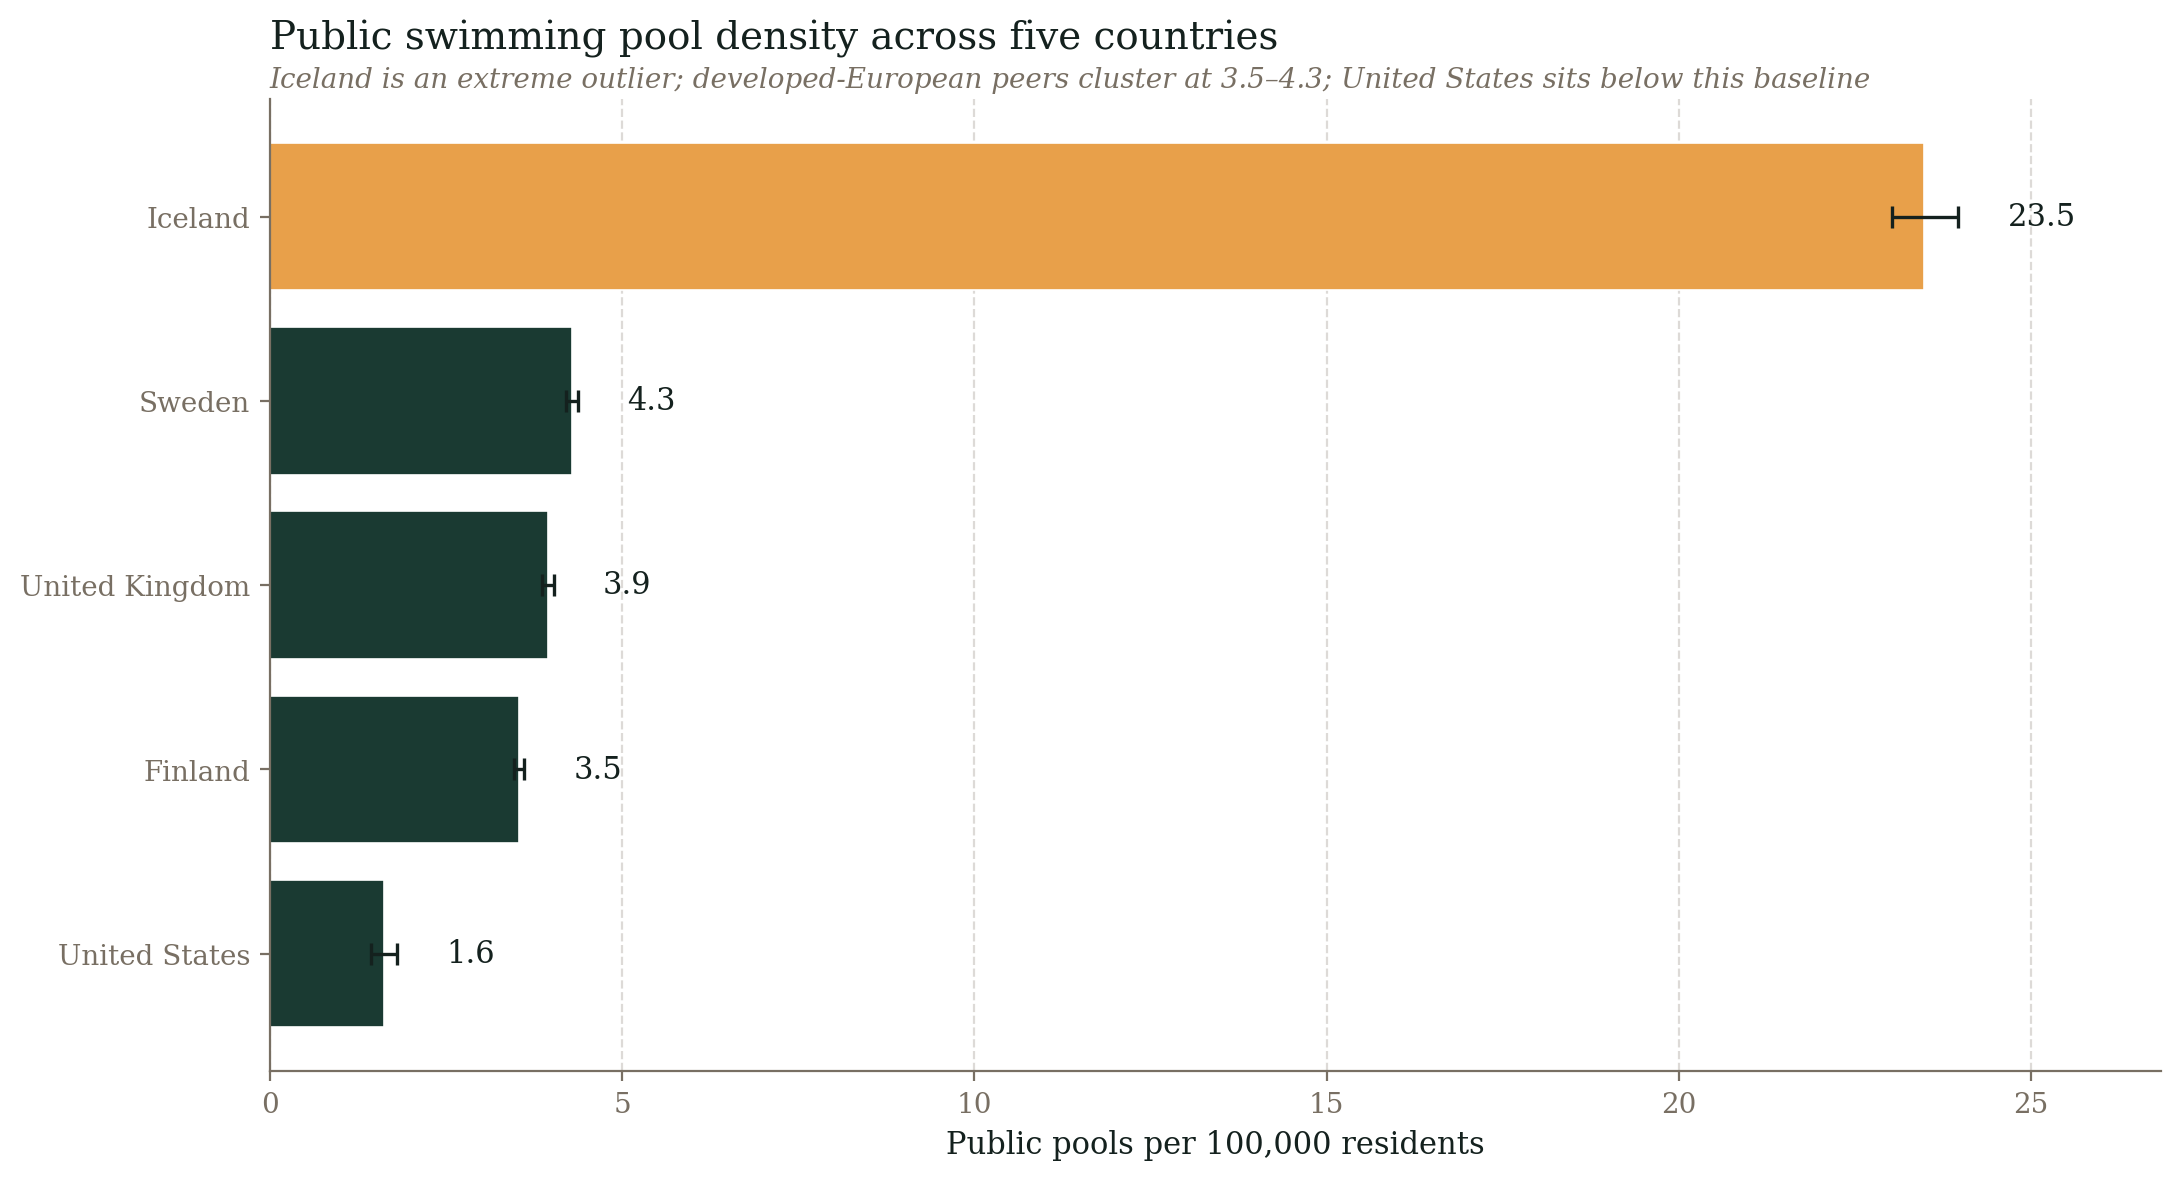

In [2]:
# Display the country comparison chart inline
display(Image(filename=str(OUTPUTS / 'country_comparison_chart.png')))

## 2. Findings

### 2.1 Country comparison

Figure 1 (above) shows per-capita public swimming pool density across the five countries in the analysis, with uncertainty bars reflecting the methodological treatment described in Section 1.4. Three findings emerge from the comparison.

**Finding 1: Iceland is an extreme outlier.** Iceland operates at 23.5 public pools per 100,000 residents (range 23.0–24.0). This is approximately five to six times the rate of the next-densest country in the dataset (Sweden, 4.3 per 100,000) and roughly 14 times the United States rate (1.6 per 100,000). At Iceland's per-capita rate, the United States would have approximately 80,000 public pools rather than the ~5,500 it actually has.

Iceland's density is not driven by small-country quirks. The country has 18 public pools in the greater Reykjavík capital area alone (population ~240,000), a per-capita rate of 7.5 per 100,000 — still substantially above any other country's national average. The high density holds across the country, in regions with population densities below those of rural United States. The geothermal heating that makes pool operations economically viable is the most-cited explanation, though documenting the full causal story is beyond this report's scope.

**Finding 2: Three European countries form a tight cluster within this sample.** Sweden (4.3), United Kingdom (3.95), and Finland (3.5) span a range of less than one point. The cluster includes both Nordic countries (Sweden, Finland) and a non-Nordic European country (UK), suggesting the density pattern is not Nordic-specific within this sample. Their uncertainty ranges overlap with one another, making the three statistically indistinguishable at the precision of this measurement. Whether this clustering generalizes to the broader set of developed European countries — Germany, France, the Netherlands, Norway, Denmark, and others not in this sample — is a question this report does not address.

**Finding 3: The United States sits substantially below the European cluster in this sample.** The US per-capita rate of 1.6 per 100,000 (range 1.4–1.8) is approximately 40% of the average rate of the three European peers in this sample (~3.9 per 100,000). The gap is robust to the count uncertainty: even at the upper bound of our US estimate (1.8 per 100,000), the rate remains below the lower bound of the European cluster. The United States is the only country in the analysis whose uncertainty range does not overlap with the European cluster.

The combined picture: Iceland operates a category-distinct public-pool infrastructure; three European countries in this sample operate at similar rates; the United States operates at roughly half the rate of these European peers. The cross-country variation is substantially larger than the variation within any single country's measurement uncertainty, supporting the interpretation that the observed patterns reflect real differences rather than measurement artifacts.

In [3]:
# Display the sensitivity scenarios table inline for reference
sensitivity[['country', 'definition', 'pools', 'per_100k']].round(2)

,country,definition,pools,per_100k
0,Iceland,strict (verified),93,23.48
1,Iceland,inclusive (tourism),120,30.30
2,Finland,indoor only (LIPAS),198,3.54
3,Finland,indoor + outdoor est.,300,5.36
4,United Kingdom,public leisure centres,2646,3.95
5,United Kingdom,council-operated only,898,1.34
6,Sweden,verified,450,4.29
7,United States,midpoint estimate,5500,1.62


### 2.2 Sensitivity to definitional choices

The table above presents per-capita rates under alternative definitions for the three countries where defensible alternatives existed. Two questions matter for the report's central findings: does Iceland's outlier status survive alternative definitions, and does the US-vs-European gap survive alternative definitions?

**Iceland's outlier status is robust.** Under our strict definition (93 pools), Iceland operates at 23.5 per 100,000. Under the more inclusive definition cited in tourism literature (120 pools, including lagoons, hot springs, and natural pools), the rate rises to 30.3 per 100,000. The choice of definition shifts Iceland's value but does not affect its outlier status: even at the strict count, Iceland is more than five times the European cluster average within this sample. At the inclusive count, the multiple grows to roughly seven times. The headline finding — Iceland is in a category by itself — does not depend on which definitional choice was made.

**Finland's category placement is robust.** Under our preferred definition (198 indoor swimming halls), Finland operates at 3.5 per 100,000, placing it within the European cluster. Including outdoor pools and reasonably-priced spas raises the estimate to approximately 5.4 per 100,000, which would shift Finland slightly above Sweden but keep it within the broader European-peer cluster in this sample. Finland's relative position is preserved across the definitional range.

**The United Kingdom's count requires methodological care.** Under our preferred definition (2,646 publicly-accessible pools), the UK is at 3.95 per 100,000, placing it firmly within the European cluster. An alternative narrower definition — restricted to facilities directly operated by local councils, excluding those operated by private leisure-management companies under municipal contracts — produces 898 facilities and a per-capita rate of 1.34 per 100,000.

This narrower count would place the UK below the United States rather than within the European cluster, fundamentally changing the cross-country picture. We address this directly.

The 898 figure measures *operational arrangements*, not *public access*. Pools operated by GLL, Everyone Active, or Freedom Leisure under contract with local authorities are publicly accessible to anyone who walks in and pays a per-visit fee, in the same way Swedish or Icelandic public pools are. The shift toward outsourced operation in the UK since the 1990s reflects changes in municipal employment patterns, not in the public-good function of the facilities. Comparing the UK's directly-council-operated count (898) against other countries' all-public-access counts would compare unlike quantities — a methodologically inappropriate comparison.

We acknowledge that this is a definitional choice. A different study could legitimately apply a stricter "direct public operation" definition uniformly across all countries — but such a study would need to apply that strictness consistently to Sweden's privately-operated facilities, US YMCA-operated facilities, and so on. The comparison framing in this report treats "publicly accessible, regulated public access" as the operative criterion. The alternative narrow definition tested here is documented for transparency, not adopted.

**Summary of sensitivity findings.** The two headline patterns — Iceland's exceptional density, and the gap between the US and the three European peers in this sample — survive defensible alternative definitions. The one case where definitional choice matters (UK's narrow vs. broad count) is addressed by a methodological argument rather than by changing the definition: the narrow count is inappropriate for the comparison being made.

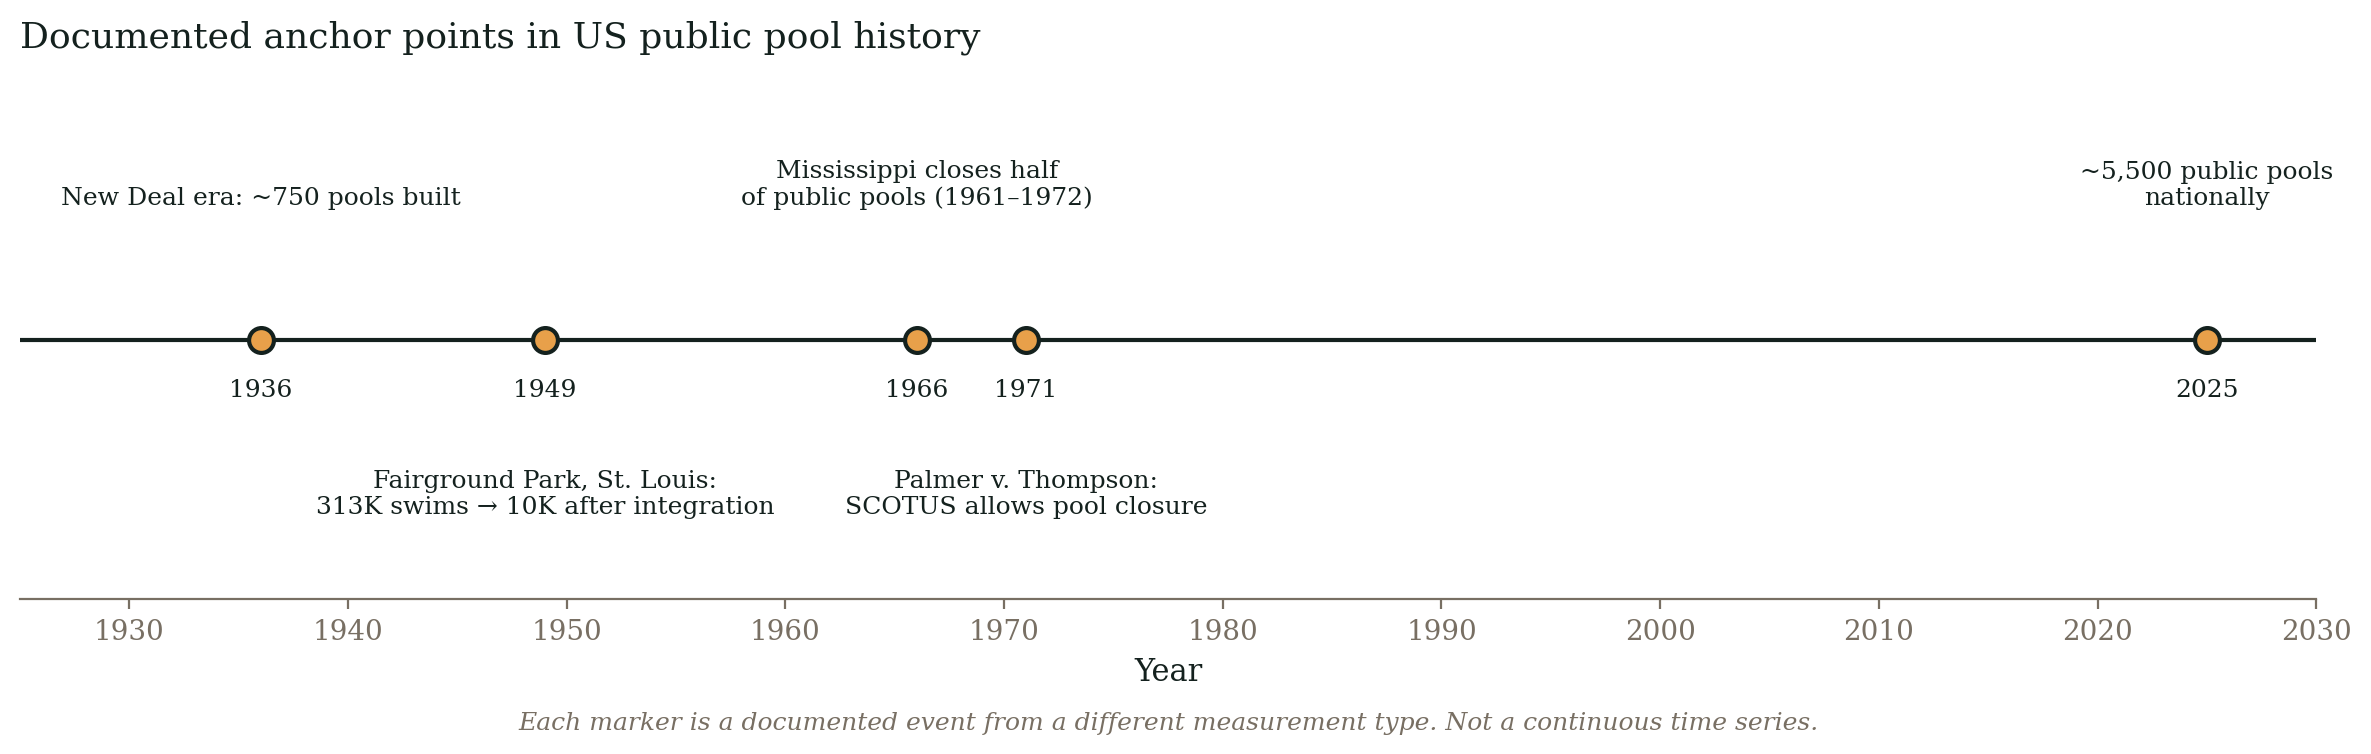

In [4]:
# Display the US historical anchor-point chart inline
display(Image(filename=str(OUTPUTS / 'us_historical_anchors_chart.png')))

## 3. Historical Context

### 3.1 The dominant scholarly account of the US public pool gap

The cross-country data documented in Section 2 raises an obvious question: why does the United States have so few public pools relative to developed-European peers? The dominant scholarly explanation, advanced by historian Jeff Wiltse in *Contested Waters: A Social History of Swimming Pools in America* (University of North Carolina Press, 2007), points to a specific historical mechanism centered on the desegregation era.

The figure above shows documented anchor points in this history, presented as discrete events rather than as a continuous time series — each marker measures a different quantity (construction count, attendance figures, state-level rate change, current national total) and they are not analytically combinable. The points are nonetheless illustrative of the broad pattern Wiltse documents.

The argument, as transmitted through secondary sources citing Wiltse's book, runs as follows.

The United States underwent a significant public pool construction boom in the 1920s and 1930s. The New Deal era specifically funded approximately 750 public pools through Works Progress Administration and Public Works Administration programs between 1933 and 1939 — a federal investment in public recreational infrastructure with few historical parallels. These pools, like the Fairground Park Pool built in St. Louis in 1919, were sometimes the largest in the world at the time of construction, designed for thousands of swimmers simultaneously.

Through the 1920s and 1940s, most US public pools were segregated by race, either through formal policy or unwritten convention. When courts began ordering desegregation in the late 1940s and early 1950s, many municipalities responded by closing pools rather than integrating them, or by allowing facilities to fall into disrepair as white attendance dropped sharply.

The Fairground Park Pool case is the most-documented example. In summer 1948, the pool recorded approximately 313,000 swims. Court-ordered desegregation took effect in summer 1949, triggering significant unrest. By summer 1950, the same pool recorded approximately 10,000 swims — a 97% decline in attendance. The pool closed permanently in 1956.

Similar patterns appear across other US cities and states. Wiltse documents a broader pattern of pool closures, deferred maintenance, and white shift to private and backyard pools through the 1950s and 1960s. A study in *Southeastern Geographer* documented that Mississippi closed approximately half of its public pools between 1961 and 1972. The 1971 Supreme Court case *Palmer v. Thompson* effectively legalized the practice: the Court ruled that Jackson, Mississippi could close four of its five public pools (and transfer the fifth to a whites-only YMCA) rather than integrate them, on the grounds that the closures affected all residents equally.

By the time of the Civil Rights Act of 1964 and the era of formal legal desegregation, the public pool infrastructure that had been built in the 1920s-1930s had been substantially reduced. New municipal pool construction, which had peaked in the New Deal era, slowed dramatically. Private and backyard pools expanded to fill the recreational gap — but as private substitutes, not as public infrastructure.

The desegregation-era account is widely cited but should be read as one of several structural explanations for the contemporary US public-pool gap rather than as the sole cause. Suburbanization beginning in the 1950s shifted recreational demand outside the central-city neighborhoods where most public pools were concentrated, weakening the political constituency for new municipal pool investment. The rise of backyard pool ownership through the 1960s, 1970s, and 1980s privatized a substantial share of US swimming infrastructure, further reducing demand for public facilities. State and municipal fiscal pressures from the 1970s onward — particularly after California's Proposition 13 and similar tax-revolt measures — reduced new capital investment in public recreation broadly, of which pools were one casualty. The desegregation-era pool closures Wiltse documents are part of this longer structural transformation, not separate from it.

The current US count of approximately 5,500 public pools — and the per-capita rate of 1.6 per 100,000 documented in Section 2 — is the cumulative consequence of these overlapping mid-century structural shifts.

### 3.2 What this report does and does not claim about this history

This report's analytical contribution is in the cross-country measurement documented in Section 2. The historical account in Section 3.1 is presented as context for that measurement — specifically, as one widely-cited scholarly explanation for the gap between the US and the European peers in this sample. The historical interpretation is attributed to Wiltse (2007) and to secondary journalism citing Wiltse's work.

The authors of this report did not consult Wiltse's primary text directly. The historical claims here are sourced from secondary materials that cite Wiltse, including journalism in *Marketplace* and *NextSTL*, and from Heather McGhee's *The Sum of Us* (One World, 2021), which uses the Fairground Park case as an opening example in her broader argument about how racism shapes public policy. We acknowledge this dependency as a limitation in Section 4.

What we are not claiming: we are not advancing the desegregation-era explanation as a causal claim of this report, nor are we claiming it is the sole or even the dominant structural cause of the contemporary US pool gap. We are documenting that this is one widely-cited scholarly account, and presenting the major points of that account as faithfully as our secondary sources allow. A reader who wants to evaluate the historical interpretation in depth should consult Wiltse's book directly. A fuller structural account of the US public-pool gap would also examine suburbanization patterns, the rise of private recreational substitutes, and municipal fiscal pressure — factors named briefly in Section 3.1 but not analyzed in this report.

## 4. Limitations

Several limitations of this analysis warrant explicit acknowledgment.

### 4.1 Country selection

The five-country sample was chosen for analytical convenience and tractability: each has an authoritative or near-authoritative national source for public pool counts, and the set spans the analytical structure of interest (one high outlier, three peers, one low outlier). This selection-on-structure approach is appropriate for descriptive analysis but limits the generalizability of the findings. A larger comparison set, particularly one including Southern European, Eastern European, East Asian, and Oceanic countries, might reveal that the European cluster identified in this sample is itself a regional phenomenon rather than a global one. The US-vs-European-cluster framing should be read as documenting one specific comparison, not as establishing a global norm.

### 4.2 Definitional choices

The strict definition applied (Section 1.2) excluded several categories of facility that other studies might reasonably include: school pools accessible to the public, hotel pools, private clubs, splash pads, seasonal-only outdoor pools, and natural bathing sites without constructed facilities. The sensitivity analysis (Section 2.2) tested how the headline findings move under defensible alternative definitions; the findings are robust to these alternatives in nearly all cases. The one case requiring methodological argument — the UK council-operated narrow count — is addressed in Section 2.2.

A different study with different research questions would reasonably apply different definitions. The choices documented here are not the only correct choices; they are choices made to support the specific comparative question the report addresses.

### 4.3 Measurement uncertainty in the US count

The United States count of approximately 5,500 public pools is the only figure in the dataset that is itself an estimate rather than an enumerated total. The 5,000–6,000 plausible range was derived from a Trust for Public Land analysis of the 100 most populous US cities, scaled to national population. The methodology assumes the top-100 cities are representative of national patterns, which may not hold for rural counties or smaller municipalities. A national directory of US public pools comparable to Iceland's sundlaugar.is or Finland's LIPAS database does not exist. The uncertainty bounds reported in Section 2 reflect this measurement variability, but the underlying gap to an authoritative US count remains.

We note further that the reported 1.4–1.8 range may itself understate true uncertainty. The bounded range captures count variability within the Trust for Public Land analytical framework, but it does not capture uncertainty in the scaling assumption — that the top-100-cities pattern is representative of national patterns — which is itself a structural source of variability the reported range does not quantify. A true uncertainty range that incorporated this structural source of variability would likely be wider than 1.4–1.8. The conclusion that the US sits below the European cluster in this sample survives this widening (the European cluster lower bound is approximately 3.4 per 100,000, well above any plausible upper bound for the US under reasonable widening), but the precise magnitude of the gap is less precise than the reported range alone suggests.

### 4.4 Secondary-source dependency for the historical interpretation

The historical context presented in Section 3 is sourced from journalism and other secondary materials citing Wiltse (2007). The authors of this report did not consult Wiltse's primary text directly within the project timeline. This dependency has several implications:

- Specific page citations to *Contested Waters* are not provided. A reader wishing to verify the report's historical claims should locate the relevant sections in Wiltse's book.
- The selection of which Wiltse claims to present is shaped by which claims the secondary sources chose to highlight. The historical record covered in Section 3 may therefore underrepresent aspects of Wiltse's argument that are less widely discussed in journalism.
- Quotes attributed to Wiltse in this report come from secondary citations, not from Wiltse's text directly. They are treated as paraphrases rather than as verbatim quotes.

This is the report's most significant methodological limitation. We acknowledge it explicitly to allow the reviewer to weigh the historical section appropriately. The cross-country measurement work in Sections 1 and 2 stands independently of this limitation; the historical context in Section 3 should be read as faithful transmission of a scholarly argument rather than as independent verification of it.

### 4.5 Scope decisions

Several lines of inquiry that would have strengthened the report were not pursued, primarily due to timeline constraints:

- **City-level walking-shed analysis.** A comparison of how far the median resident of selected cities (e.g., Reykjavík vs. Phoenix or Denver) lives from the nearest public pool would have provided a tangible complement to the national-level density comparison.
- **Historical anchor points beyond Wiltse.** Additional documentation of the 1950s–1970s pool decline period — e.g., specific city-level construction and closure records — would have strengthened the historical section beyond the major events covered.
- **Comparison to additional developed European countries.** Germany, France, the Netherlands, and Norway would each have provided useful additional data points for testing whether the three-country European cluster identified in this sample generalizes more broadly.

These represent extensions worth pursuing in a follow-up analysis. They are not gaps that undermine the present report's findings; they are paths the present report did not take.

### 4.6 What this comparison measures

The strict definition applied in this analysis (Section 1.2) counts only publicly-operated or publicly-regulated facilities. A consequence is that the cross-country comparison partly measures *how each country socializes recreational infrastructure*, not solely *how many swimming pools each country has*. Countries with strong traditions of municipal recreational provisioning will appear higher in this kind of comparison than countries that rely more heavily on private, commercial, or institutional facilities to meet recreational demand, even if total bathing capacity were similar under a broader definition.

This is not a flaw in the analysis; it is a property of what the analysis sets out to measure. A "public swimming pool density" comparison is, in effect, a comparison of public-provisioning philosophies as much as a comparison of infrastructure quantity. The United States's low position in the rankings, for example, reflects partly a lower count of publicly-operated pools and partly the substitution of private and backyard pools for what would be public infrastructure elsewhere. The two are interrelated and a strict per-capita-public-pools metric does not fully disentangle them.

We document this explicitly so the report's findings are not read as straightforward claims about total swimming capacity, or about how often residents of each country actually swim. The report documents one specific public-provisioning outcome — per-capita publicly-operated swimming pool density — and the cross-country variation in that outcome is genuinely large. Whether that variation reflects different total recreational supply or different decisions about how to socialize that supply is a question this report raises but does not resolve.

## 5. References

### Scholarly sources

McGhee, Heather. *The Sum of Us: What Racism Costs Everyone and How We Can Prosper Together*. New York: One World, 2021.

Wiltse, Jeff. *Contested Waters: A Social History of Swimming Pools in America*. Chapel Hill: University of North Carolina Press, 2007. Available via Internet Archive: https://archive.org/details/contestedwaterss0000wilt

### Primary data sources

**Iceland.** Sundlaugar.is. National public pool directory. Accessed May 13, 2026. https://sundlaugar.is/en/swimming-pools/

**Finland.** LIPAS — National Sport Facility Database. University of Jyväskylä, in cooperation with the Finnish Ministry of Education and Culture. Cited via: Suomi, K., et al. *Liikuntapaikkojen tila ja kehittämistarpeet Suomessa* (Sports Facilities Status and Development Needs in Finland). University of Oulu, 2015.

**Sweden.** BeFair. "Sveriges simhallar — fakta och statistik." Industry research summary, accessed May 14, 2026. Confirmed by Swedish Swimming Federation (Svenska Simförbundet) reporting.

**United Kingdom.** Leisure Database Company. *2024 State of the UK Swimming Industry Report*. London: Leisure DB, 2024.

**United States.** Trust for Public Land. Public swimming pool data compiled via Swimply analytical report, accessed May 13, 2026. Methodology described at: https://www.swimply.com/

### Secondary journalism cited

Marketplace (American Public Media). "Public pools used to be everywhere in America. Then racism shut them down." February 15, 2021. https://www.marketplace.org/story/2021/02/15/public-pools-used-to-be-everywhere-in-america-then-racism-shut-them-down

NextSTL. Coverage of Fairground Park Pool historical record, including 1949 desegregation events and subsequent closure.

### Population data

National population figures (Iceland, Finland, Sweden, United Kingdom, United States) sourced from Statistics Iceland (Hagstofa Íslands), Statistics Finland (Tilastokeskus), Statistics Sweden (SCB), Office for National Statistics (UK), and US Census Bureau, respectively. All figures are 2024 estimates.

---

*Report prepared in support of somewhere-else.org publication week 2: "Sundlaug Country." For the public-facing article based on these findings, see the published version at somewhere-else.org (publishes Tuesday May 19, 2026).*

---

## Report status and next steps

**Report status:** Draft submitted for peer review, May 17, 2026.

**Reviewer:** [Name and affiliation withheld pending publication; specialist in sociology and ethics.]

**Review focus areas requested:**

1. **Methodology** — Are the definitional choices, uncertainty treatment, and sensitivity analysis appropriate for the stated research question? Are there methodological objections that the report does not anticipate or address?
2. **Sourcing rigor** — Are the cross-country data sources appropriately authoritative? Are any claims overstated relative to what the sources support?
3. **Handling of historical context** — Section 3 presents Wiltse's argument as transmitted through secondary sources. Is the attribution explicit enough? Is the limitation (Section 4.4) acknowledged with appropriate weight? Are there ways the section could overrepresent or misrepresent the scholarly account?
4. **Tone and framing** — The report engages with a politically charged topic (desegregation-era pool closures in the United States) within an analytical register. Does the tone hold up? Are there phrases that should be softened or strengthened?

**Anticipated revision timeline:**

- Reviewer feedback expected: Monday May 18, 2026
- Revisions incorporated: Monday afternoon
- Final report locked: Monday evening
- Public-facing article (based on this report) publishes: Tuesday May 19, 2026 at 10 AM PT

**Acknowledgments:**

This report was prepared as the second installment of a weekly publishing project at somewhere-else.org. The author thanks the reviewer for the time and care offered in this review process. The author also acknowledges the analytical and editorial support of Claude (Anthropic), used as a writing and analysis partner throughout the project's reconnaissance, data analysis, and report drafting phases. All editorial decisions, methodological choices, and final responsibility for the report's claims rest with the named author.

---

*End of report.*